In [2]:
from datasets import load_from_disk
import numpy as np
import os
import torch
from scipy.special import log_softmax, softmax
import matplotlib.pyplot as plt
from expected_cost.utils import plot_hists

In [11]:
seeds = {
    4: [295, 603, 702, 801, 900, 926, 962, 999, 2951, 9622],
    8: [505, 604, 639, 703, 802, 901, 923, 932, 6391, 9322]
}
size2lorasamples = {4: 10, 8: 20}
for n in seeds:
    print("Size:", n)
    for seed in seeds[n]:
        print("Seed:", seed, end=" ")
        experiment_path = f"../experiments/agnews_{n}_{seed}/basic_agnews_0-shot_litgpt/lm_tinyllama/lora_{size2lorasamples[n]}samples/affine_scalar_train_on_val"
        for split in ["train", "val"]:
            data = load_from_disk(os.path.join(experiment_path, f"predictions/cal_{split}")).with_format("numpy")
            targets = data["label"].astype(int)
            priors = np.bincount(targets, minlength=4) / len(targets)
            print(f"{split}: {priors}", end=" ")
        data = load_from_disk(os.path.join(experiment_path, f"predictions/test")).with_format("numpy")
        logprobs = log_softmax(data["logits"], axis=1)
        targets = data["label"].astype(int)
        ce = -np.mean(logprobs[np.arange(logprobs.shape[0]), targets])
        priors = np.bincount(targets) / len(targets)
        naive_ce = -np.sum(priors * np.log(priors))
        print(f"Norm CE: {ce/naive_ce:.03}", end=" ")
        
        data = load_from_disk(os.path.join(experiment_path, f"predictions/validation")).with_format("numpy")
        targets = data["label"].astype(int)
        priors = np.bincount(targets, minlength=4) / len(targets)
        print(f"Validation priors: {priors}")
    print(f"Test priors: {priors}")
    print()

Size: 4
Seed: 295 train: [0.33333333 0.         0.33333333 0.33333333] val: [0.5 0.5 0.  0. ] Norm CE: 0.375 Validation priors: [0.4 0.2 0.2 0.2]
Seed: 603 train: [0.33333333 0.66666667 0.         0.        ] val: [0.5 0.  0.5 0. ] Norm CE: 0.432 Validation priors: [0.4 0.4 0.2 0. ]
Seed: 702 train: [0.         0.66666667 0.         0.33333333] val: [0.5 0.  0.5 0. ] Norm CE: 0.605 Validation priors: [0.2 0.4 0.2 0.2]
Seed: 801 train: [0. 1. 0. 0.] val: [0.  0.5 0.5 0. ] Norm CE: 0.382 Validation priors: [0.  0.8 0.2 0. ]
Seed: 900 train: [0.66666667 0.33333333 0.         0.        ] val: [0.5 0.  0.  0.5] Norm CE: 0.566 Validation priors: [0.6 0.2 0.  0.2]
Seed: 926 train: [0.33333333 0.66666667 0.         0.        ] val: [0.5 0.5 0.  0. ] Norm CE: 0.579 Validation priors: [0.4 0.6 0.  0. ]
Seed: 962 train: [0.         0.66666667 0.33333333 0.        ] val: [0.5 0.  0.5 0. ] Norm CE: 1.0 Validation priors: [0.2 0.4 0.4 0. ]
Seed: 999 train: [0.33333333 0.         0.66666667 0.       

Seed 564 - Norm CE: 0.464 (no_calibration) - Norm CE: 0.71 (affine_scalar_train_on_val) - Alpha: 0.9974880218505859; Beta: tensor([-0.0402,  0.0402]) - Epoch: 0
Seed 738 - Norm CE: 0.452 (no_calibration) - Norm CE: 6.11e-06 (affine_scalar_train_on_val) - Alpha: 29.699861526489258; Beta: tensor([ 2.0049, -5.3913]) - Epoch: 29
Seed 783 - Norm CE: 0.497 (no_calibration) - Norm CE: 0.27 (affine_scalar_train_on_val) - Alpha: 1.3019863367080688; Beta: tensor([ 0.1001, -0.1001]) - Epoch: 0
Seed 7832 - Norm CE: 0.84 (no_calibration) - Norm CE: 1.06 (affine_scalar_train_on_val) - Alpha: 1.0866398811340332; Beta: tensor([ 0.5067, -0.5067]) - Epoch: 0
Seed 5641 - Norm CE: 0.452 (no_calibration) - Norm CE: 5.44e-06 (affine_scalar_train_on_val) - Alpha: 25.735557556152344; Beta: tensor([-11.7843,   8.9792]) - Epoch: 29
[0.42857143 0.57142857]
[1.]
[0 0 0]


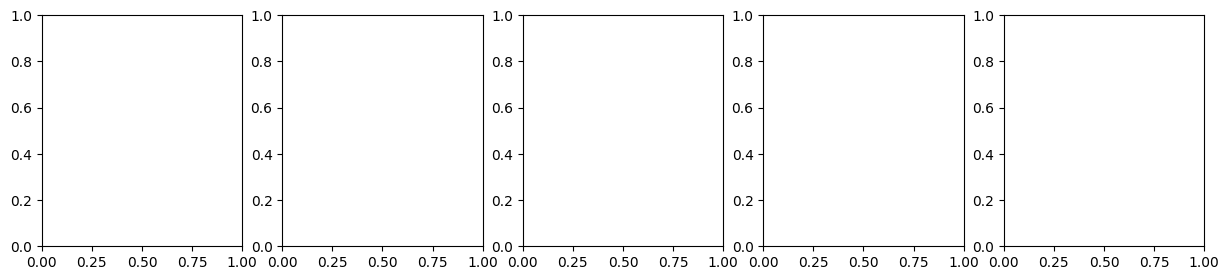

In [80]:
seeds = [564, 738, 783, 7832, 5641]
fig, ax = plt.subplots(1, len(seeds), figsize=(15,3))
_fig, _ax = plt.subplots(1, len(seeds), figsize=(15,3))
for i, seed in enumerate(seeds):
    print(f"Seed {seed}", end=" - ")
    for method, prefix in zip(["no_calibration", "affine_scalar_train_on_val"], ["", "cal_"]):
        experiment_path = f"../experiments/sst2_16_{seed}/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_20samples/{method}"
        data = load_from_disk(os.path.join(experiment_path, f"predictions/{prefix}train")).with_format("numpy")
        logprobs = log_softmax(data["logits"], axis=1)
        probs = softmax(data["logits"], axis=1)
        targets = data["label"].astype(int)
        ce = -np.mean(logprobs[np.arange(logprobs.shape[0]), targets])
        priors = np.bincount(targets) / len(targets)
        naive_ce = -np.sum(priors * np.log(priors))
        print(f"Norm CE: {ce/naive_ce:.03} ({method})", end=" - ")

        scores = logprobs
        # ax[i].hist(scores[targets == 1, 1], bins=50, alpha=0.5, label=method, density=True)
        # ax[i].set_title(f"Seed {seed}")
        # ax[i].set_xlim(0, 1)
    
    model = torch.load(os.path.join(experiment_path, "best.ckpt"), map_location="cpu")
    print(f"Alpha: {model['state_dict']['calibrator.alpha']}; Beta: {model['state_dict']['calibrator.beta']}", end=" - ")
    print(f"Epoch: {model['epoch']}")
# print(model["state_dict"].keys())
plt.close(_fig)

data = load_from_disk(os.path.join(experiment_path, f"predictions/cal_train")).with_format("numpy")
targets = data["label"].astype(int)
print(np.bincount(targets) / len(targets))
data = load_from_disk(os.path.join(experiment_path, f"predictions/cal_val")).with_format("numpy")
targets = data["label"].astype(int)
print(np.bincount(targets) / len(targets))
print(targets)

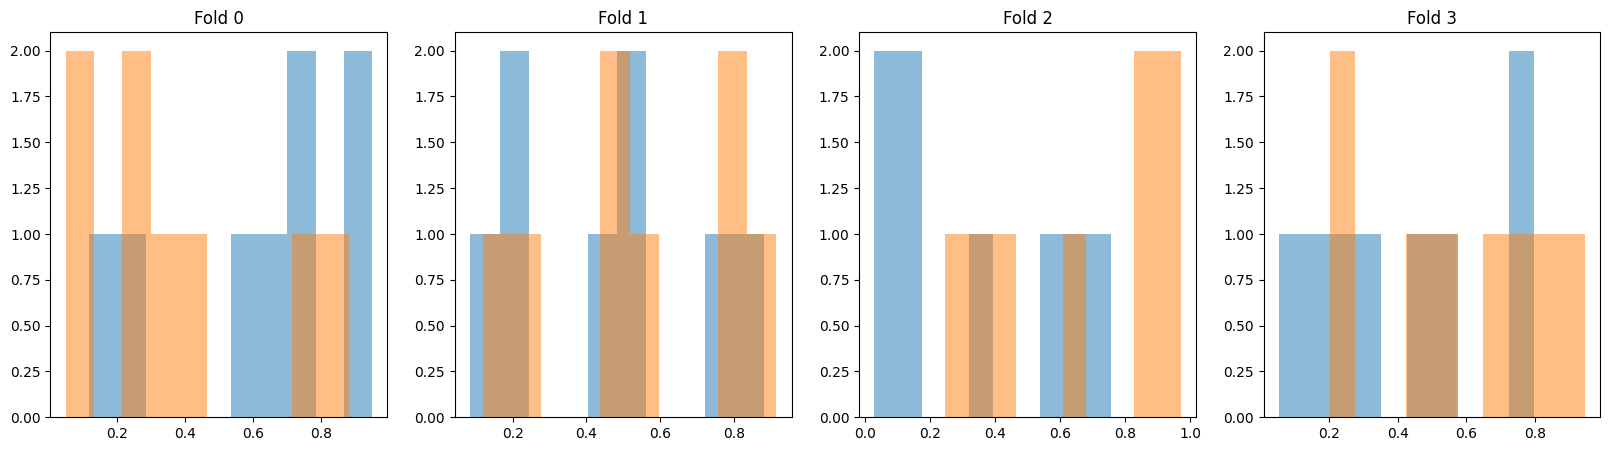

In [20]:
# experiment_path = "../experiments/sst2_8_639/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_xval_10samples/.cache"
experiment_path = "../experiments/sst2_16_564/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_xval_20samples/.cache"
# experiment_path = "../experiments/dbpedia_4_926/basic_dbpedia_0-shot_litgpt/lm_tinyllama/lora_xval_60samples/.cache"

# ckpt = torch.load(os.path.join(experiment_path, "fold_0/last.ckpt"))
# plot_hists(targets, logprobs, outfile=None, nbins=4, group_by='score', style='-', label_prefix='', axs=None)
nfolds = 4
fig, ax = plt.subplots(1, nfolds, figsize=(20, 5))
for f in range(nfolds):
    data = load_from_disk(os.path.join(experiment_path, f"fold_{f}/predictions")).with_format("numpy")
    # scores = log_softmax(data["logits"], axis=1)
    scores = softmax(data["logits"], axis=1)
    targets = data["label"]
    for i in range(scores.shape[1]):
        ax[f].hist(scores[:, i], bins=10, alpha=0.5, label=f"class {i}")
    ax[f].set_title(f"Fold {f}")

Norm CE: 0.5421509914097452
Norm CE: 3.264958668166293
Norm CE: 1.0847538909987615
Norm CE: 0.8763605713154714
Norm CE: 4.762277891028349


array([<Axes: title={'center': 'Scores from col 0'}>,
       <Axes: title={'center': 'Scores from col 1'}>], dtype=object)

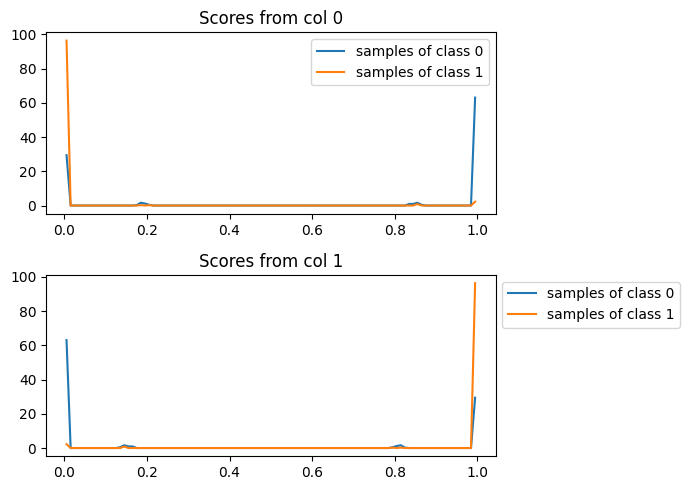

In [29]:
for seed in [564, 738, 783, 7832, 5641]:
    experiment_path = f"../experiments/sst2_16_{seed}/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_20samples/affine_scalar_train_on_val"
    # experiment_path = "../experiments/sst2_256_812/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_500samples/affine_scalar_train_on_val"
    # fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    data = load_from_disk(os.path.join(experiment_path, f"predictions/test")).with_format("numpy")
    scores = log_softmax(data["logits"], axis=1)
    # scores = softmax(data["logits"], axis=1)
    targets = data["label"]
    ce = -np.mean(scores[np.arange(scores.shape[0]), targets])
    priors = np.bincount(targets) / len(targets)
    naive_ce = -np.sum(priors * np.log(priors))
    print(f"Norm CE: {ce/naive_ce}")
# for i in range(scores.shape[1]):
#     ax.hist(scores[:, i], bins=50, alpha=0.5, label=f"class {i}")
scores = softmax(data["logits"], axis=1)
plot_hists(targets, scores, outfile=None, nbins=100, group_by='score', style='-', label_prefix='', axs=None)

(array([ 0,  0,  0,  0,  0, 13,  0,  0,  0,  0]), array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5],
      dtype=float32))
(array([5, 1, 0, 0, 0, 0, 0, 0, 0, 3]), array([5.043902e-21, 1.000000e-01, 2.000000e-01, 3.000000e-01,
       4.000000e-01, 5.000000e-01, 6.000000e-01, 7.000000e-01,
       8.000000e-01, 9.000000e-01, 1.000000e+00], dtype=float32))

(array([1, 0, 0, 0, 0, 0, 0, 0, 0, 3]), array([0.9999851 , 0.9999866 , 0.9999881 , 0.99998957, 0.99999106,
       0.99999255, 0.99999404, 0.9999955 , 0.999997  , 0.9999985 ,
       1.        ], dtype=float32))
(array([5, 0, 0, 0, 0, 0, 0, 0, 0, 1]), array([1.3921464e-19, 6.5322616e-04, 1.3064523e-03, 1.9596785e-03,
       2.6129046e-03, 3.2661308e-03, 3.9193570e-03, 4.5725834e-03,
       5.2258093e-03, 5.8790352e-03, 6.5322616e-03], dtype=float32))

(array([ 10,   4,   0,   0,   0,   0,   0,   1,   1, 428]), array([7.093466e-17, 1.000000e-01, 2.000000e-01, 3.000000e-01,
       4.000000e-01, 5.000000e-01, 6.000000e-01, 7.0000

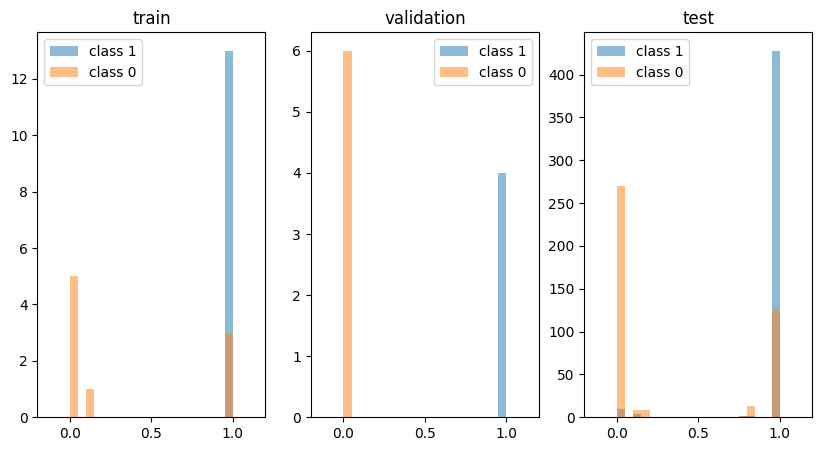

In [70]:
seed = 5641
experiment_path = f"../experiments/sst2_16_{seed}/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_20samples/affine_scalar_train_on_val"
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
for i, split in enumerate(["train", "validation", "test"]):
    data = load_from_disk(os.path.join(experiment_path, f"predictions/{split}")).with_format("numpy")
    # scores = log_softmax(data["logits"], axis=1)
    scores = softmax(data["logits"], axis=1)
    targets = data["label"]
    ax[i].hist(scores[targets == 1, 1], bins=20, range=(0,1), alpha=.5, label=f"class 1")
    ax[i].hist(scores[targets == 0, 1], bins=20, range=(0,1), alpha=.5, label=f"class 0")
    ax[i].set_xlim(-0.2, 1.2)
    print(np.histogram(scores[targets == 1, 1]))
    print(np.histogram(scores[targets == 0, 1]))
    print()
    ax[i].set_title(split)
    ax[i].legend()

In [72]:
data = load_from_disk(os.path.join(experiment_path, f"predictions/validation")).with_format("numpy")
scores = softmax(data["logits"], axis=1)
# np.histogram(scores, bins=20)
scores.shape

(10, 2)